# Load Cleaned Data 

In [1]:
import pandas as pd
df=pd.read_csv(r'C:\Users\akash\Downloads\cleaned_data.csv')
df.head()

,sku,product_type,price,availability,number_of_products_sold,stock_levels,lead_time,supplier_name,transportation_modes,costs,delay_days,effective_lead_time
0,SKU0,haircare,69.8080,55,802,58,29,Supplier 3,Road,187.752,2,31
1,SKU1,skincare,14.8435,95,736,53,23,Supplier 3,Road,503.066,1,24
2,SKU2,haircare,11.3197,34,8,1,12,Supplier 1,Air,141.920,0,12
3,SKU3,skincare,61.1633,68,83,23,24,Supplier 5,Rail,254.776,3,27
4,SKU4,skincare,4.8055,26,871,5,5,Supplier 1,Air,923.441,2,7


# Prepare Data for Forecasting

In [2]:
import numpy as np
df['date']=pd.date_range(start="2024-01-01",periods=len(df),freq="D")
df["date"]=df["date"] + pd.to_timedelta(np.random.randint(0,5,len(df)), unit="D")

# Creating Time Series

In [3]:
import pandas as pd
df["date"]=pd.to_datetime(df["date"])
df=df.sort_values("date")
ts=df.groupby("date")["number_of_products_sold"].sum()

# Handle Missing Dates

In [4]:
ts=ts.asfreq("D")
ts=ts.fillna(0)

# Visualize Data

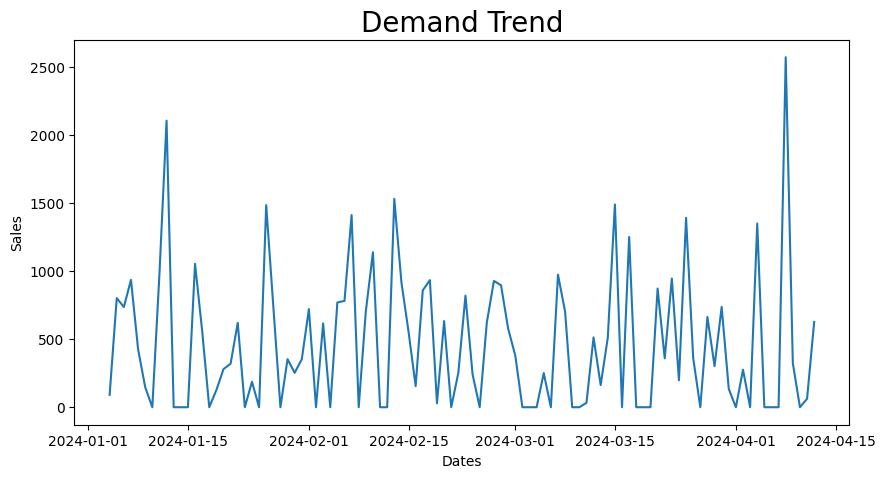

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Demand Trend",fontsize=20)
plt.xlabel("Dates")
plt.ylabel("Sales")
plt.show()

# Model 1-Moving Average


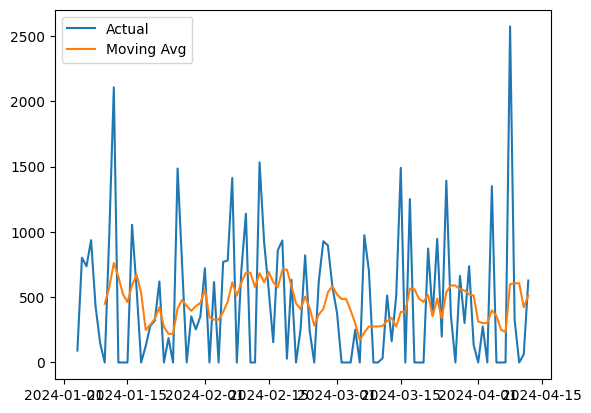

In [6]:
ts_ma=ts.rolling(window=7).mean()
plt.plot(ts,label="Actual")
plt.plot(ts_ma, label="Moving Avg")
plt.legend()
plt.show()

# Model 2-ARIMA

In [7]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(ts,order=(1,1,1))
model_fit=model.fit()
forecast=model_fit.forecast(steps=7)
print(forecast)

C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2024-04-13    448.143684
2024-04-14    461.050557
2024-04-15    460.119154
2024-04-16    460.186367
2024-04-17    460.181516
2024-04-18    460.181866
2024-04-19    460.181841
Freq: D, Name: predicted_mean, dtype: float64


# Plot Forecast

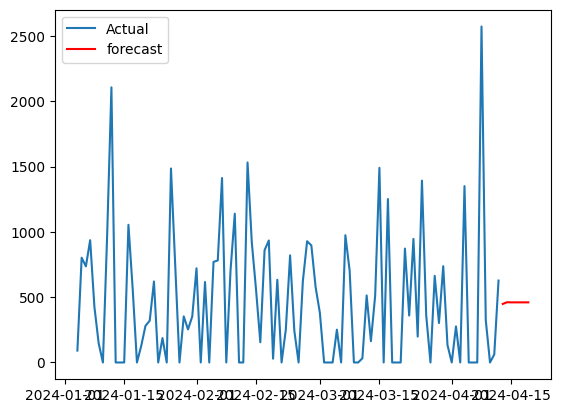

In [8]:
plt.plot(ts,label="Actual")
plt.plot(forecast,label="forecast",color="red")
plt.legend()
plt.show()

# Model 3 - Machine Learning

In [10]:
df["day"]=df["date"].dt.day
df["month"]= df["date"].dt.month

In [11]:
from sklearn.ensemble import RandomForestRegressor
X=df[["day","month","stock_levels"]]
y=df["number_of_products_sold"]
model=RandomForestRegressor()
model.fit(X,y)
df["forecast_ml"]=model.predict(X)

# Compare Actual vs ML

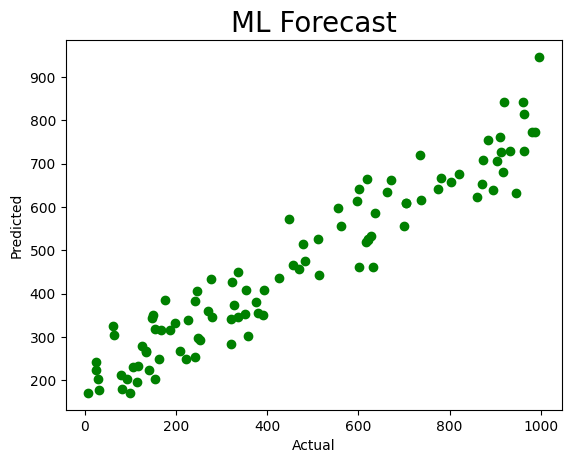

In [12]:
plt.scatter(df["number_of_products_sold"],df["forecast_ml"],color="green")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("ML Forecast",fontsize=20)
plt.show()

# Detect Overstock

In [13]:
df["overstock"]=df["stock_levels"]>df["forecast_ml"]*1.5

# Detect Stockout

In [14]:
df["stockout_risk"] = df["stock_levels"]<df["forecast_ml"]

# Save Final Data


In [16]:
import os

save_path = r"C:\Users\akash\Downloads\final_forecast_data.csv"
df.to_csv(save_path, index=False)
print(f"File saved to: {save_path}")

File saved to: C:\Users\akash\Downloads\final_forecast_data.csv
